In [2]:
import numpy as np
import csv
from implementations import *
from tqdm import tqdm


In [3]:
train_path = "./data/x_train.csv"
with open(train_path, "r") as f:
    header = np.array(next(csv.reader(f)))

x_train = np.genfromtxt(train_path, delimiter=",", dtype=float, skip_header=1)

In [4]:
y_true = np.genfromtxt("./data/y_train.csv", delimiter=",", dtype=float, skip_header=1)[:,1]

In [5]:
def loss(y: np.array, y_true: np.array) -> float:
    return np.mean((y-y_true)**2)

In [6]:
threshold = .75
nPeople, nFeatures = x_train.shape

non_NaN_dominant_cols = np.sum(~np.isnan(x_train), axis=0)
# print(NaN_dominant_cols)
mask_col = non_NaN_dominant_cols/nPeople > threshold
header = header[mask_col]

x_train_filtered_columns = x_train[:, mask_col]
print(f'{100*x_train_filtered_columns.shape[1]/nFeatures:.2f}% of columns kept')


non_NaN_dominant_rows = np.sum(~np.isnan(x_train_filtered_columns), axis=1)
mask_row = non_NaN_dominant_rows/x_train_filtered_columns.shape[1] > threshold

x_train_filtered = x_train_filtered_columns[mask_row, :]
y_true = y_true[mask_row]

nPeople, nFeatures = x_train_filtered.shape
print(f'{100*x_train_filtered.shape[0]/nPeople:.2f}% of people kept')
print(f"Final shape: {x_train_filtered.shape} (original shape: {x_train.shape})")


44.72% of columns kept
100.00% of people kept
Final shape: (323065, 144) (original shape: (328135, 322))


In [7]:
epsilon = .001
x_mean = np.mean(x_train_filtered, axis=0)
x_std = np.std(x_train_filtered, axis=0) + 1e-8
sx = (x_train_filtered - x_mean) / x_std
sx = np.nan_to_num(sx, nan=0.0)

y_mean = np.mean(y_true)
sy = y_true - y_mean

print(sx.shape, sy.shape, (sx.T@sy).squeeze().shape)

lambda_max = np.max(np.abs(sx.T @ sy).squeeze()) / nPeople
epsilon = 0.001
epochs = 10
nPeople, nFeatures = sx.shape

lambdas = np.logspace( np.log10(lambda_max), np.log10(lambda_max * epsilon), num=epochs)

weights_path = np.zeros((epochs, nFeatures))



(323065, 144) (323065,) (144,)


In [8]:
pbar = tqdm(enumerate(lambdas), total=epochs, desc="Learning...")
min_loss = np.inf
#for i, lmbda in pbar:
#    w = ridge_regression(sy, sx, lmbda)
#    current_loss = loss(sx@w, sy)
#    min_loss = min(min_loss, current_loss)
#    weights_path[i] = w
#    pbar.set_postfix({"loss": f"{min_loss:.4f}", "lambda": f"{lmbda:.4f}"})


final_weights = weights_path[np.argmin([loss(sx@w, sy) for w in weights_path])]
abs_weights = np.abs(final_weights)



Learning...:   0%|          | 0/10 [00:00<?, ?it/s]

In [9]:
top_k = 50
top_k_indices = np.argsort(abs_weights)[::-1]

top_k_headers = header[top_k_indices]
top_k_weights = final_weights[top_k_indices]

print(f"\n--- Top {top_k} Features correlated with y ---")
for h, w in zip(top_k_headers[:top_k], top_k_weights[:top_k]):
    print(f"{h:<25}: {w:+.4f}")


--- Top 50 Features correlated with y ---
_AIDTST3                 : +0.0000
_RFSEAT3                 : +0.0000
_RFSEAT2                 : +0.0000
_LMTSCL1                 : +0.0000
_LMTWRK1                 : +0.0000
_LMTACT1                 : +0.0000
_PASTAE1                 : +0.0000
_PAREC1                  : +0.0000
_PASTRNG                 : +0.0000
_PA30021                 : +0.0000
_PA300R2                 : +0.0000
_PA150R2                 : +0.0000
_PAINDX1                 : +0.0000
_PACAT1                  : +0.0000
PAMISS1_                 : +0.0000
STRFREQ_                 : +0.0000
FC60_                    : +0.0000
MAXVO2_                  : +0.0000
_TOTINDA                 : +0.0000
_VEGETEX                 : +0.0000
_FRUITEX                 : +0.0000
_VEG23                   : +0.0000
_FRT16                   : +0.0000
_VEGLT1                  : +0.0000
_FRTLT1                  : +0.0000
_VEGESUM                 : +0.0000
_FRUTSUM                 : +0.0000
_VEGRESP    

In [10]:
def print_by_name(name):
    index = np.where(top_k_headers == name)[0]
    print(f"P-factor = {top_k_weights[index]}, rank = {index}/{top_k_headers.size}")


In [11]:
print_by_name("_BMI5")

P-factor = [0.], rank = [49]/144


In [12]:
x_test = np.genfromtxt("./data/x_test.csv", delimiter=",", dtype=float, skip_header=1)

In [13]:
x_test_filtered = x_test[:, mask_col]

In [14]:
x_test_mean = np.mean(x_test_filtered, axis=0)
x_test_std = np.std(x_test_filtered, axis=0) + 1e-8
sx_test = (x_test_filtered - x_test_mean) / x_test_std
sx_test = np.nan_to_num(sx_test, nan=0.0)

[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]


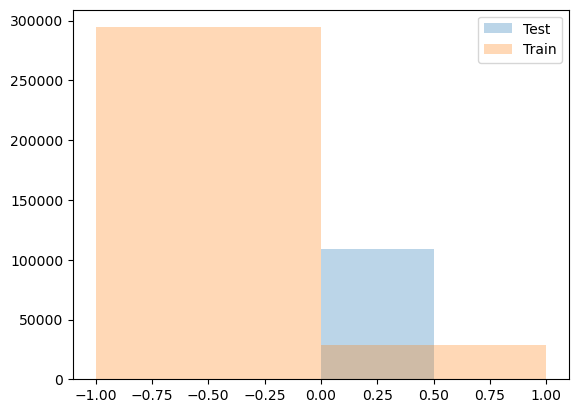

In [15]:
import matplotlib.pyplot as plt
y_test = sx_test@final_weights
print(y_test)
y_test = np.where(y_test < 0, -1, y_test)
y_test = np.where(y_test > 0, 1, y_test)
print(y_test)
plt.hist(y_test, bins=2, alpha=0.3, label="Test")
plt.hist(y_true, bins=2, alpha=0.3, label="Train")
plt.legend()


In [16]:
correlations = np.abs(sx.T@sy)/len(sy)
top_k_mask = correlations > np.percentile(correlations, 70)
sx_filtered = sx[:, top_k_mask]

U, S, Vt = np.linalg.svd(sx_filtered, full_matrices=False)
scores_train = U*S
x_test_scaled = (x_test_filtered - x_mean)/x_std
x_test_scaled = x_test_scaled[:, top_k_mask]
print(U.shape, S.shape, Vt.shape, x_test_scaled.shape)

scores_test = x_test_scaled@Vt.T

k = 15
scores_train_k = scores_train[:, :k]
scores_test_k = scores_test[:, :k]

N_train = scores_train_k.shape[0]
N_test = scores_test_k.shape[0]
train_sq = np.sum(scores_train_k**2, axis=1)
nearest_train_idx = np.zeros(N_test, dtype=int)

batch_size = 1000

for start_idx in tqdm(range(0, N_test, batch_size), desc="Streaming distances..."):
    end_idx = min(start_idx + batch_size, N_test) #otherwise crashes on last batch

    test_batch = scores_test_k[start_idx:end_idx]
    test_sq_batch = np.sum(test_batch ** 2, axis=1)

    distance = (test_sq_batch[:, None] + train_sq[None, :] - 2 * (test_batch @ scores_train_k.T))
    

    nearest_train_idx[start_idx:end_idx] = np.argmin(distance, axis=1)

y_pred = y_true[nearest_train_idx]


(323065, 43) (43,) (43, 43) (109379, 43)


Streaming distances...: 100%|██████████| 110/110 [03:44<00:00,  2.04s/it]


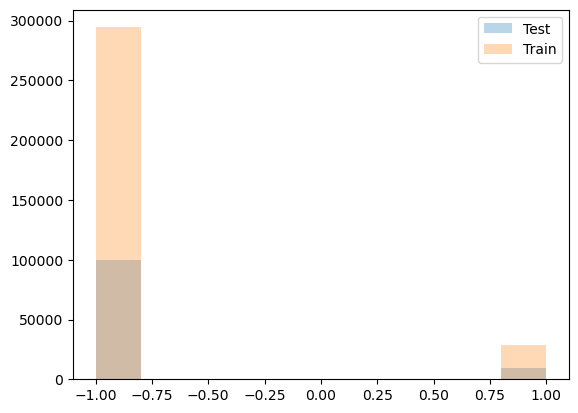

In [17]:
plt.hist(y_pred, alpha=0.3, label="Test")
plt.hist(y_true, alpha=0.3, label="Train")
plt.legend()

In [18]:
N_confirm = 1000

confirm_scores_k = scores_train_k[:N_confirm] 
y_confirm = y_true[:N_confirm]

confirm_sq = np.sum(confirm_scores_k ** 2, axis=1)
distance = (confirm_sq[:, None] + train_sq[None, :] - 2 * (confirm_scores_k @ scores_train_k.T))

np.fill_diagonal(distance, np.inf) # Ignore self matching values otherwise it doesn't really make much sense

nearest_confirm_idx = np.argmin(distance, axis=1)

y_pred = y_true[nearest_confirm_idx]

In [19]:
Nerrors = np.sum(y_pred != y_confirm)
print(f"{Nerrors} errors made out of {N_confirm} ~ {100 * Nerrors / N_confirm:.2f}% error rate")

144 errors made out of 1000 ~ 14.40% error rate


In [21]:
x_test.shape

(109379, 322)

In [24]:
with open("./data/sample_submission.csv", "w") as f:
    f.write("Id,Prediction\n")
    for i in range(y_pred.size):
        f.write(f"{int(x_test[i,0])},{y_pred[i]}\n")
